In [1]:
import networkx as nx
from cdlib.algorithms import leiden, louvain, infomap, walktrap
from time import time
import numpy as np
import math

Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer', 'bayanpy', 'graph_tool'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer'}


In [2]:
def tic():
    return time()

def toc(start):
    return time() - start

In [3]:
G = nx.read_graphml("KRvKP_7_updated.graphml")
G = nx.convert_node_labels_to_integers(G)
print(f"n: {G.number_of_nodes()}")
print(f"m: {G.number_of_edges()}")

n: 177557
m: 1017308


In [4]:
def save(G, filename):
    reverse_map = {node_id: data["label"] for node_id, data in G.nodes(data=True)}
    G_restored = nx.relabel_nodes(G, reverse_map)
    nx.write_graphml(G, f"{filename}.graphml")

In [7]:
def set_communities_to_graph(G, communities, algorithm_name):
    for i, c in enumerate(communities):
        for u in c:
            G.nodes[u][algorithm_name] = i

def get_communities(G, algorithm, verbose=False):
    #algorithms = {"louvain": louvain, "leiden": leiden, "infomap": infomap, "walktrap": walktrap}
    #algorithms = {"leiden": leiden}
    
    start = tic()
    try:
        result = algorithm(G)
    except TypeError as e:
        G_ = G.to_undirected()
        result = algorithm(G_)
    t = toc(start)
    if verbose:
        print(f"Time taken: {t:.2f}s")
    return result

In [8]:
result = get_communities(G, leiden, verbose=True)
set_communities_to_graph(G, result.communities, leiden.__name__)

Time taken: 15.45s


In [9]:
save(G, "KRvKP_7_updated_updated")

In [10]:
G.nodes[0]

{'label': '3r4/2k5/5P2/7K/8/8/8/8:b:2',
 'wdl': 2,
 'Cluster': 0,
 'Inferred Class': 0,
 'size': 4.0,
 'r': 0,
 'g': 106,
 'b': 111,
 'x': -349.77667,
 'y': -11541.133,
 'leiden': 1}

In [11]:
def filter_communities(communities, threshold=0.01):
    return {i: c for i, c in enumerate(communities) if len(c)/len(nodes) >= threshold}

In [12]:
win_frequency = dict()
loss_frequency = dict()
draw_frequency = dict()

nodes = list(G.nodes())
communities = filter_communities(result.communities)

for i, c in communities.items():
    wins = 0
    losses = 0
    draws = 0
    for u in c:
        if G.nodes[u]["wdl"] == 2:
            wins += 1
        elif G.nodes[u]["wdl"] == -2:
            losses += 1
        elif G.nodes[u]["wdl"] == 0:
            draws += 1
    win_frequency[i] = wins/len(c)
    loss_frequency[i] = losses/len(c)
    draw_frequency[i] = draws/len(c)

In [13]:
win_frequency = dict(sorted(win_frequency.items(), key=lambda item: -item[1]))
loss_frequency = dict(sorted(loss_frequency.items(), key=lambda item: -item[1]))
draw_frequency = dict(sorted(draw_frequency.items(), key=lambda item: -item[1]))

In [14]:
draw_frequency

{25: 0.948509485094851,
 29: 0.876051598429613,
 27: 0.845941468801767,
 10: 0.8443285996764336,
 7: 0.8330045095828635,
 8: 0.6377164115037917,
 4: 0.5593807763401109,
 0: 0.5029219663114473,
 9: 0.4809272300469484,
 5: 0.4802967083912842,
 20: 0.44670846394984326,
 22: 0.44061505832449627,
 12: 0.4103060829135994,
 13: 0.35564663023679416,
 16: 0.34979633401221993,
 3: 0.2917313234316116,
 28: 0.1875,
 1: 0.1826515610135778,
 6: 0.15689481630598892,
 11: 0.11075014766686356,
 17: 0.10810810810810811,
 21: 0.06958355297838692,
 18: 0.06956521739130435,
 14: 0.05896686159844054,
 26: 0.057003257328990226,
 24: 0.05183585313174946,
 19: 0.04490861618798955,
 15: 0.0337573385518591,
 23: 0.03210272873194221,
 2: 0.009982757055994192}

In [15]:
win_frequency

{15: 0.9329745596868885,
 11: 0.8892498523331365,
 19: 0.8851174934725848,
 26: 0.8697068403908795,
 18: 0.8557544757033249,
 17: 0.815910249872514,
 1: 0.7163365908501254,
 3: 0.6149412547107072,
 23: 0.5409309791332263,
 22: 0.5302226935312832,
 21: 0.4881391671059568,
 24: 0.48272138228941686,
 28: 0.42367256637168144,
 0: 0.39678583705740805,
 6: 0.28447408152994463,
 16: 0.23828920570264767,
 5: 0.23041261010662958,
 7: 0.16502254791431792,
 13: 0.16347905282331512,
 4: 0.16266173752310537,
 9: 0.15507629107981222,
 27: 0.154058531198233,
 10: 0.1540535682185871,
 2: 0.13748979036210182,
 8: 0.13220775504364002,
 29: 0.12394840157038699,
 12: 0.0976365749709415,
 20: 0.08254963427377221,
 25: 0.051490514905149054,
 14: 0.0}

In [16]:
loss_frequency

{14: 0.9410331384015594,
 2: 0.852527452581904,
 6: 0.5586311021640664,
 12: 0.49205734211545915,
 13: 0.4808743169398907,
 20: 0.47074190177638453,
 24: 0.4654427645788337,
 21: 0.4422772799156563,
 23: 0.42696629213483145,
 16: 0.4119144602851324,
 28: 0.38882743362831856,
 9: 0.36399647887323944,
 5: 0.28929068150208626,
 4: 0.2779574861367837,
 8: 0.23007583345256832,
 1: 0.10101184813629681,
 0: 0.10029219663114472,
 3: 0.09332742185768123,
 17: 0.07598164201937786,
 18: 0.07468030690537085,
 26: 0.0732899022801303,
 19: 0.06997389033942558,
 15: 0.033268101761252444,
 22: 0.02916224814422057,
 7: 0.001972942502818489,
 10: 0.0016178321049793278,
 11: 0.0,
 25: 0.0,
 27: 0.0,
 29: 0.0}

In [14]:
def get_barycenter(G, community):
    G_ = G.subgraph(community)
    G_ = G_.to_undirected()
    return nx.barycenter(G_)[0]

In [67]:
barycenter = get_barycenter(G, result.communities[13])

In [68]:
G.nodes[barycenter]

{'label': '3r4/2k5/5P2/8/5K2/8/8/8:b:2',
 'wdl': 2,
 'Modularity Class': 0,
 'Inferred Class': 17,
 'Cluster': 7,
 'size': 10.0,
 'r': 255,
 'g': 87,
 'b': 255,
 'x': 531.94666,
 'y': 2833.6394,
 'louvain': 12,
 'leiden': 13,
 'infomap': 4,
 'walktrap': 6}

In [17]:
def get_barycenters(G, communities):
    return {i: get_barycenter(G, c) for i, c in communities.items()}

def get_edges_between_communities(G, communities):
    skeleton_edges = {(i, j): set() for i in communities.keys() for j in communities.keys() if i != j}

    comm = {u: i for i, c in communities.items() for u in c}
    for (u, v) in G.edges():
        c_u = comm.get(u, None)
        c_v = comm.get(v, None)
        if c_u == c_v or c_u is None or c_v is None:
            continue

        skeleton_edges[(c_u, c_v)].add((u, v))

    return skeleton_edges

In [18]:
community_edges = get_edges_between_communities(G, communities)
community_edges

{(0, 1): {(143851, 161193),
  (64126, 77665),
  (104710, 126041),
  (75424, 165004),
  (104733, 127336),
  (64049, 75575),
  (69608, 74035),
  (107594, 173645),
  (165531, 177129),
  (74158, 145787),
  (106624, 156031),
  (64035, 69297),
  (146686, 165570),
  (105521, 127945),
  (75444, 170925),
  (63836, 63309),
  (143827, 160957),
  (76566, 76870),
  (64025, 65805),
  (143798, 160750),
  (67913, 107142),
  (75409, 170823),
  (72697, 143598),
  (66097, 67371),
  (65932, 70947),
  (143893, 160758),
  (76632, 76442),
  (72840, 143646),
  (106638, 156581),
  (106649, 156819),
  (76533, 76814),
  (72831, 142514),
  (74215, 145215),
  (106980, 170839),
  (64051, 63620),
  (104709, 126058),
  (75452, 170677),
  (71064, 75166),
  (143933, 161324),
  (63834, 63362),
  (156070, 174636),
  (156351, 172291),
  (66111, 70810),
  (105577, 128204),
  (105499, 127647),
  (63917, 76493),
  (72829, 142562),
  (143881, 161435),
  (143892, 160770),
  (104714, 126145),
  (157713, 173661),
  (75413, 17031

In [19]:
#barycenters = get_barycenters(G, communities)
#barycenters

In [20]:
def get_community_graph(G, communities):
    #barycenters = get_barycenters(G, communities)
    community_edges = get_edges_between_communities(G, communities)

    G_community = nx.DiGraph()

    for (c_u, c_v), edges in community_edges.items():
        if len(edges) >= 1:
            G_community.add_edge(c_u, c_v)

    for i, c in communities.items():
        u = c[0]
        G_community.nodes[i]["x"] = G.nodes[u]["x"]
        G_community.nodes[i]["y"] = G.nodes[u]["y"]
    
    return G_community

def draw_community_graph(G_community, communities):
    pos = dict()
    for u, data in G_community.nodes(data=True):
        x = data["x"]
        y = data["y"]
        pos[u] = (x, y)
        
    comm = {u: i for i, c in communities.items() for u in c}
    node_colors = []
    for c in G_community.nodes():
        w = win_frequency.get(c, 0)
        l = loss_frequency.get(c, 0)
        d = draw_frequency.get(c, 0)
    
        wl = w + l
    
        r = l / wl
        g = w / wl
    
        r = r * (1 - d)
        g = g * (1 - d)
        
        node_colors.append((r, g, 0))
        
    return nx.draw(G_community, pos=pos, node_color=node_colors, with_labels=True, font_color="white")

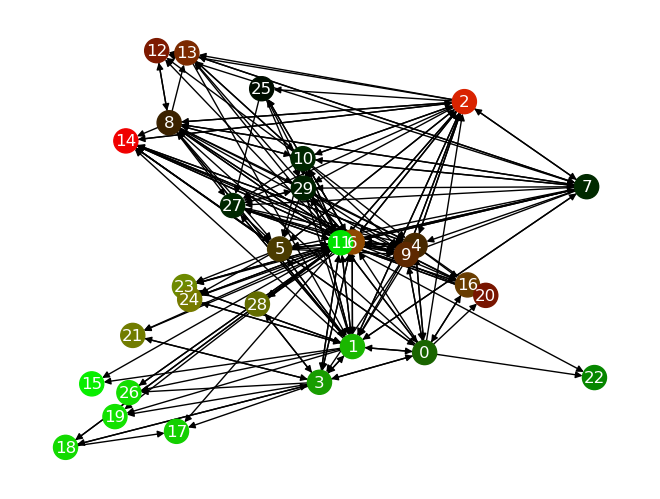

In [21]:
G_community = get_community_graph(G, communities)
draw_community_graph(G_community, communities)

In [22]:
G.nodes[0]

{'label': '3r4/2k5/5P2/7K/8/8/8/8:b:2',
 'wdl': 2,
 'Cluster': 0,
 'Inferred Class': 0,
 'size': 4.0,
 'r': 0,
 'g': 106,
 'b': 111,
 'x': -349.77667,
 'y': -11541.133,
 'leiden': 1}

In [61]:
start_node = 0 # 3r4/2k5/5P2/7K/8/8/8/8:b:2 <=> 3r4/2k5/5P2/7K/8/8/8/8 b - - 0 1
all_paths = nx.single_source_shortest_path(G, source=start_node)
barycenter_paths = {}

for comm_i, barycenter in barycenters.items():
    path = all_paths[barycenter]
    barycenter_paths[comm_i] = path

NameError: name 'barycenters' is not defined

In [110]:
barycenter_paths

{0: [0, 1, 19163, 1893],
 1: [0, 1, 19181, 3912],
 2: [0, 2, 19501, 42],
 3: [0, 1, 19181, 3912, 4545],
 4: [0, 2, 19143, 2576, 1065],
 5: [0, 1, 19181, 3912, 4546],
 6: [0, 1, 19163, 1893, 1066],
 7: [0, 1, 19147, 2608, 1064],
 8: [0, 1, 19181, 3912, 1063],
 9: [0, 2, 19180, 3928, 1062],
 10: [0],
 11: [0, 1, 19163, 1893, 2892],
 12: [0, 1, 19147, 2608, 2889],
 13: [0, 1, 19163, 1893, 2890],
 14: [0, 1, 19163, 1893, 2891],
 15: [0, 1, 19181, 3912, 4547],
 16: [0, 1, 19181, 3912, 2887],
 17: [0, 2, 19501, 42, 1070],
 18: [0, 2, 19501, 42, 1069]}

In [23]:
# 1 - W + L
def get_community_scores():
    community_scores = dict()
    for comm_i in win_frequency.keys():
        w = win_frequency[comm_i]
        l = loss_frequency[comm_i]
        
        score = 1 - w + l
        community_scores[comm_i] = score
    return community_scores

In [24]:
def Q_norm(communities, alpha, win_frequency, loss_frequency, draw_frequency):
    Q = dict()
    
    for i, c in communities.items():
        w = win_frequency[i]
        d = draw_frequency[i]
        Q[i] = w + (1 - alpha) * d
        
    return Q     

In [25]:
# best/ideal community (by get_community_scores) to get to is 13
community_scores = get_community_scores()
community_scores = dict(sorted(community_scores.items(), key=lambda item: -item[1]))
community_scores

{14: 1.9410331384015596,
 2: 1.7150376622198023,
 12: 1.3944207671445177,
 20: 1.3881922675026124,
 13: 1.3173952641165756,
 6: 1.2741570206341217,
 9: 1.2089201877934272,
 16: 1.1736252545824848,
 4: 1.1152957486136783,
 8: 1.0978680784089283,
 5: 1.0588780713954566,
 24: 0.9827213822894169,
 28: 0.9651548672566372,
 21: 0.9541381128096995,
 25: 0.948509485094851,
 23: 0.8860353130016052,
 29: 0.876051598429613,
 10: 0.8475642638863923,
 27: 0.845941468801767,
 7: 0.8369503945885006,
 0: 0.7035063595737368,
 22: 0.49893955461293743,
 3: 0.4783861671469741,
 1: 0.38467525728617147,
 17: 0.2600713921468638,
 18: 0.218925831202046,
 26: 0.20358306188925077,
 19: 0.18485639686684074,
 11: 0.11075014766686353,
 15: 0.10029354207436397}

In [26]:
# best/ideal community (by get_community_scores) to get to is 13
alpha = 0.5
Q = Q_norm(communities, alpha, win_frequency, loss_frequency, draw_frequency)
Q = dict(sorted(Q.items(), key=lambda item: -item[1]))
Q

{15: 0.949853228962818,
 11: 0.9446249261665682,
 19: 0.9075718015665796,
 26: 0.8982084690553747,
 18: 0.890537084398977,
 17: 0.8699643039265681,
 1: 0.8076623713569142,
 3: 0.760806916426513,
 22: 0.7505302226935313,
 0: 0.6482468202131317,
 7: 0.5815248027057497,
 27: 0.5770292655991165,
 10: 0.5762178680568039,
 29: 0.5619742007851934,
 23: 0.5569823434991974,
 25: 0.5257452574525745,
 21: 0.5229309435951502,
 28: 0.5174225663716814,
 24: 0.5086393088552916,
 5: 0.4705609643022717,
 8: 0.45106596079553585,
 4: 0.4423521256931608,
 16: 0.4131873727087576,
 9: 0.3955399061032864,
 6: 0.3629214896829391,
 13: 0.3413023679417122,
 20: 0.3059038662486938,
 12: 0.30278961642774116,
 2: 0.14248116889009893,
 14: 0.02948343079922027}

In [27]:
# -ln(Q[c_i])
def log_metric(node):
    epsilon = 1e-9
    q_safe = max(epsilon, min(1.0, Q[node]))
    return -math.log(q_safe)

In [28]:
def apply_edge_weights(G, metric_func):
    for u, v in G.edges():
        weight = metric_func(v)
        G[u][v]["weight"] = weight

In [29]:
apply_edge_weights(G_community, log_metric)

In [30]:
costs, paths = nx.single_source_dijkstra(G_community, source=G.nodes[0]["leiden"], weight="weight")

In [31]:
costs

{1: 0,
 15: 0.05144780215187307,
 11: 0.05696733380288829,
 19: 0.09698259578940908,
 26: 0.10735308945358522,
 18: 0.17289786645416533,
 17: 0.19627043194761012,
 3: 0.273375676800543,
 22: 0.34394269244433673,
 0: 0.43348375976146125,
 7: 0.5421016549566765,
 27: 0.549862293484502,
 10: 0.5512694466479813,
 23: 0.585221738840594,
 29: 0.6332666700212187,
 24: 0.6760161406297616,
 25: 0.6999058187800874,
 21: 0.7052731964530298,
 28: 0.7158627290408659,
 5: 0.7538297549132686,
 8: 0.7961416956380544,
 4: 0.8726163834118567,
 16: 0.9408214357626536,
 9: 0.9844709302798423,
 6: 1.0135687499747634,
 13: 1.131953818889657,
 20: 1.2414517227780157,
 12: 1.251684383659971,
 2: 1.948545436145423,
 14: 3.5239268412538642}

In [32]:
paths

{1: [1],
 15: [1, 15],
 11: [1, 11],
 19: [1, 19],
 26: [1, 26],
 18: [1, 11, 18],
 17: [1, 11, 17],
 3: [1, 3],
 22: [1, 11, 22],
 0: [1, 0],
 7: [1, 7],
 27: [1, 27],
 10: [1, 10],
 23: [1, 23],
 29: [1, 11, 29],
 24: [1, 24],
 25: [1, 11, 25],
 21: [1, 11, 21],
 28: [1, 11, 28],
 5: [1, 5],
 8: [1, 8],
 4: [1, 11, 4],
 16: [1, 11, 16],
 9: [1, 11, 9],
 6: [1, 6],
 13: [1, 11, 13],
 20: [1, 11, 20],
 12: [1, 11, 12],
 2: [1, 2],
 14: [1, 14]}

In [33]:
G_sampled = nx.read_graphml("KRvKP_7_subgraph_50.graphml")
#print(list(G_sampled.nodes())[:2])
#G_sampled = nx.convert_node_labels_to_integers(G_sampled)
print(f"n: {G_sampled.number_of_nodes()}")
print(f"m: {G_sampled.number_of_edges()}")

n: 81624
m: 252296


In [34]:
mapping = dict()
for u, data in G.nodes(data=True):
    mapping[data["label"]] = u
G_sampled = nx.relabel_nodes(G_sampled, mapping)

In [35]:
print(list(G_sampled.nodes(data=True))[:2])

[(138133, {'label': 'k7/8/8/2Q4K/8/8/r7/8:w:-2', 'wdl': -2, 'Cluster': 1, 'Inferred Class': 0, 'size': 4.0, 'r': 255, 'g': 56, 'b': 0, 'x': 9460.377, 'y': 16651.373}), (148251, {'label': '4kB2/8/7K/8/8/8/r7/8:w:0', 'wdl': 0, 'Cluster': 43, 'Inferred Class': 0, 'size': 4.0, 'r': 0, 'g': 195, 'b': 0, 'x': 10744.834, 'y': 4104.562})]


In [36]:
print(list(G.nodes(data=True))[:2])

[(0, {'label': '3r4/2k5/5P2/7K/8/8/8/8:b:2', 'wdl': 2, 'Cluster': 0, 'Inferred Class': 0, 'size': 4.0, 'r': 0, 'g': 106, 'b': 111, 'x': -349.77667, 'y': -11541.133, 'leiden': 1}), (1, {'label': '7r/2k5/5P2/7K/8/8/8/8:w:2', 'wdl': 2, 'Cluster': 0, 'Inferred Class': 0, 'size': 4.0, 'r': 0, 'g': 106, 'b': 111, 'x': -496.6506, 'y': -12070.971, 'leiden': 1})]


In [37]:
result_sampled = get_communities(G_sampled, leiden, verbose=True)
set_communities_to_graph(G_sampled, result_sampled.communities, leiden.__name__)

Time taken: 5.16s


In [38]:
communities_sampled = filter_communities(result_sampled.communities)

In [71]:
from cdlib import NodeClustering

def induce_communities(G_communities, G_subgraph):
    induced_communities = []
    for arr in G_communities:
        new_arr = [x for x in arr if x in G_subgraph]
        #print(arr)
        #print(new_arr)
        if new_arr:
            induced_communities.append(new_arr)
    return induced_communities

def NMI(communities1, communities2):
    communities1 = NodeClustering(communities=communities1, graph=None)
    communities2 = NodeClustering(communities=communities2, graph=None)
    return communities1.normalized_mutual_information(communities2)

In [72]:
#induced = induce_communities(G, G_sampled, list(communities.values()))
#print(induced)

In [74]:
G_communities_induced = induce_communities(result.communities, G_sampled)
nmi = NMI(G_communities_induced, result_sampled.communities)
nmi.score

0.8667082416212528

In [100]:
G.nodes[0]

{'label': '3r4/2k5/5P2/7K/8/8/8/8:b:2',
 'wdl': 2,
 'Cluster': 0,
 'Inferred Class': 0,
 'size': 4.0,
 'r': 0,
 'g': 106,
 'b': 111,
 'x': -349.77667,
 'y': -11541.133,
 'leiden': 1}

In [102]:
import numpy as np
from numpy.random import choice

# results for this will be pessimistic
def sample_by_nodes(G, p):
    G_sampled = nx.subgraph(G, new_nodes)
    non_isolates = [n for n, d in G_sampled.degree() if d > 0]
    return nx.subgraph(G, non_isolates)

from random import random

def sample_by_dfs(G, p):
    s = 0

    G_sampled = nx.DiGraph()
    G_sampled.add_node(s, **G.nodes[s])

    stack = [s]
    S = set([s])

    while stack:
        u = stack.pop()
    
        for v in G.successors(u):
            G_sampled.add_node(v, **G.nodes[v])
            if random() < p:
                G_sampled.add_edge(u, v)
                if v not in S:
                    S.add(v)
                    stack.append(v)

    return G_sampled

def evaluate_sampled_communities_NMI(G, algorithm, p, k=10, sampling_algorithm=sample_by_nodes, verbose=False):
    nodes = list(G.nodes())
    result = get_communities(G, algorithm)
    if verbose:
        print("Calculated communities for G")
    
    NMI_list = np.zeros(k)
    
    for i in range(k):
        if verbose:
            print(f"k={i + 1}", end="\r")
        new_nodes = choice(nodes, size=int(len(nodes)*p), replace=False)

        # some sampling method
        G_sampled = sampling_algorithm(G, p)

        result_sampled = get_communities(G_sampled, algorithm)

        G_communities_induced = induce_communities(result.communities, G_sampled)
        nmi = NMI(G_communities_induced, result_sampled.communities)
        NMI_list[i] = nmi.score

    return float(np.mean(NMI_list)), float(np.std(NMI_list))

In [77]:
NMI_average, NMI_std = evaluate_sampled_communities_NMI(G, leiden, 0.5, k=10, verbose=True)

Calculated communities for G
k=10

In [82]:
print(f"NMI: {NMI_average:.3f} +-{NMI_std:.3f}")

NMI: 0.839 +-0.011


In [87]:
for p in [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]:
    print(f"Results for p = {p}")
    NMI_average, NMI_std = evaluate_sampled_communities_NMI(G, leiden, p, k=10, verbose=True)
    print(f"NMI for p = {p}: {NMI_average:.3f} +-{NMI_std:.3f}")

Results for p = 0.9
Calculated communities for G
NMI for p = 0.9: 0.906 +-0.019
Results for p = 0.8
Calculated communities for G
NMI for p = 0.8: 0.889 +-0.011
Results for p = 0.7
Calculated communities for G
NMI for p = 0.7: 0.875 +-0.018
Results for p = 0.6
Calculated communities for G
NMI for p = 0.6: 0.876 +-0.017
Results for p = 0.5
Calculated communities for G
NMI for p = 0.5: 0.849 +-0.015
Results for p = 0.4
Calculated communities for G
NMI for p = 0.4: 0.815 +-0.014
Results for p = 0.3
Calculated communities for G
NMI for p = 0.3: 0.793 +-0.014
Results for p = 0.2
Calculated communities for G
NMI for p = 0.2: 0.735 +-0.009
Results for p = 0.1
Calculated communities for G
NMI for p = 0.1: 0.633 +-0.006


In [103]:
NMI_average, NMI_std = evaluate_sampled_communities_NMI(G, leiden, 0.5, k=10, sampling_algorithm=sample_by_dfs, verbose=True)

Calculated communities for G
k=10

In [104]:
print(f"NMI: {NMI_average:.3f} +-{NMI_std:.3f}")

NMI: 0.660 +-0.017


In [105]:
NMI_average, NMI_std = evaluate_sampled_communities_NMI(G, leiden, 0.8, k=10, sampling_algorithm=sample_by_dfs, verbose=True)

Calculated communities for G
k=10

In [106]:
print(f"NMI: {NMI_average:.3f} +-{NMI_std:.3f}")

NMI: 0.821 +-0.020


In [108]:
for p in [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]:
    print(f"Results for p = {p}")
    NMI_average, NMI_std = evaluate_sampled_communities_NMI(G, leiden, p, k=10, sampling_algorithm=sample_by_dfs, verbose=True)
    print(f"NMI for p = {p}: {NMI_average:.3f} +-{NMI_std:.3f}")

Results for p = 0.9
Calculated communities for G
NMI for p = 0.9: 0.856 +-0.013
Results for p = 0.8
Calculated communities for G
NMI for p = 0.8: 0.831 +-0.010
Results for p = 0.7
Calculated communities for G
NMI for p = 0.7: 0.771 +-0.015
Results for p = 0.6
Calculated communities for G
NMI for p = 0.6: 0.716 +-0.019
Results for p = 0.5
Calculated communities for G
NMI for p = 0.5: 0.656 +-0.008
Results for p = 0.4
Calculated communities for G
NMI for p = 0.4: 0.594 +-0.013
Results for p = 0.3
Calculated communities for G
NMI for p = 0.3: 0.518 +-0.005
Results for p = 0.2
Calculated communities for G
NMI for p = 0.2: 0.436 +-0.004
Results for p = 0.1
Calculated communities for G
NMI for p = 0.1: 0.400 +-0.176
